### Fraud in Wine

- Wine fraud relates to the commercial aspects of wine. The most prevalent type of fraud is one where wines are adulterated, usually with the addition of cheaper products (e.g. juices) and sometimes with harmful chemicals and sweeteners (compensating for color or flavor).

- Counterfeiting and the relabelling of inferior and cheaper wines to more expensive brands is another common type of wine fraud.


### Project Goals

A distribution company that was recently a victim of fraud has completed an audit of various samples of wine through the use of chemical analysis on samples. The distribution company specializes in exporting extremely high quality, expensive wines, but was defrauded by a supplier who was attempting to pass off cheap, low quality wine as higher grade wine. The distribution company has hired you to attempt to create a machine learning model that can help detect low quality (a.k.a "fraud") wine samples. They want to know if it is even possible to detect such a difference.

#### 1) Importing Necessary Libraries:

In [155]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, root_mean_squared_error, roc_curve, auc
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import warnings
warnings.filterwarnings('ignore')

#### 2) Loading Data:

In [2]:
df = pd.read_csv('wine_fraud.csv')

In [3]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,Legit,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,Legit,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,Legit,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,Legit,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,Legit,red


In [4]:
df.shape

(6497, 13)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   object 
 12  type                  6497 non-null   object 
dtypes: float64(11), object(2)
memory usage: 660.0+ KB


In [6]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000


In [7]:
df['quality'].value_counts()

quality
Legit    6251
Fraud     246
Name: count, dtype: int64

- There are Numeric and Continuous Features in data.
- There are no missing values in data.
- We have a very significant class imbalance in dataset.
- We will try to use Over Sampling (SMOTE) from Imbalanced-Learn library to handle class imbalance.

#### 3) Feature Exploration and Transformations:

In [8]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,Legit,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,Legit,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,Legit,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,Legit,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,Legit,red


- There's only one categorical variable in dataset (type).

In [9]:
df['type'].value_counts()

type
white    4898
red      1599
Name: count, dtype: int64

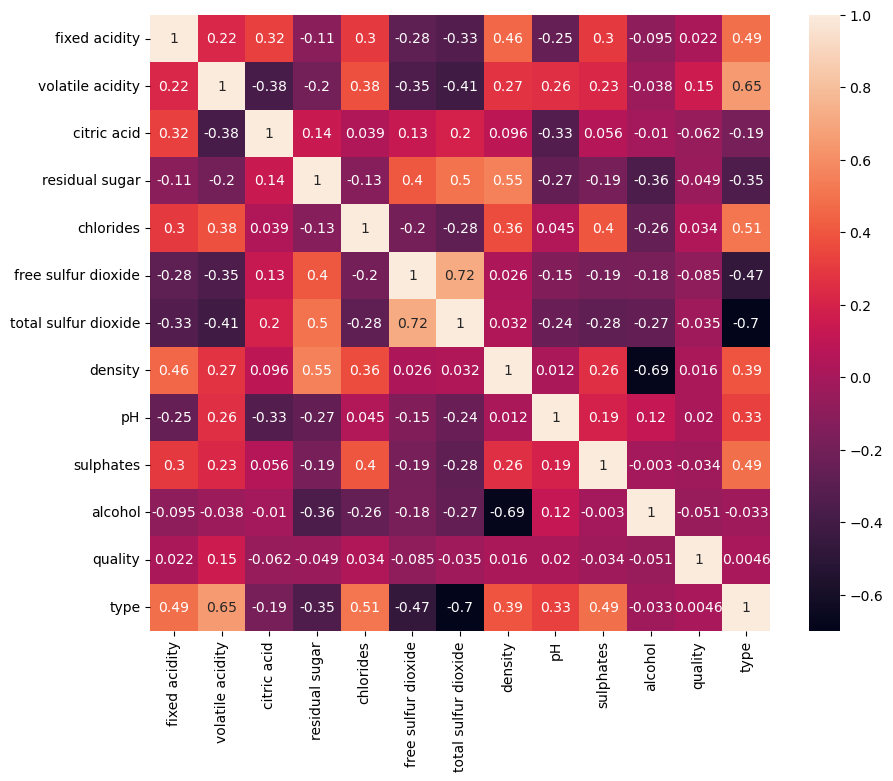

In [13]:
# Correaltions between Features and data.

temp = df.copy()

# Changing Categorical features to Numeric temporarily for correlation calculation: 
temp['quality'] = temp['quality'].map({'Legit': 0, 'Fraud': 1})
temp['type'] = temp['type'].map({'white': 0, 'red': 1})

plt.figure(figsize= (10,8), dpi= 100)
sns.heatmap(temp.corr(), annot= True)
plt.show()

- 'Quality' has no significantlly Positive or Negative Correlation with any feature.

In [15]:
df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality', 'type'],
      dtype='object')

##### 1) fixed acidity:

In [16]:
df['fixed acidity']

0        7.4
1        7.8
2        7.8
3       11.2
4        7.4
        ... 
6492     6.2
6493     6.6
6494     6.5
6495     5.5
6496     6.0
Name: fixed acidity, Length: 6497, dtype: float64

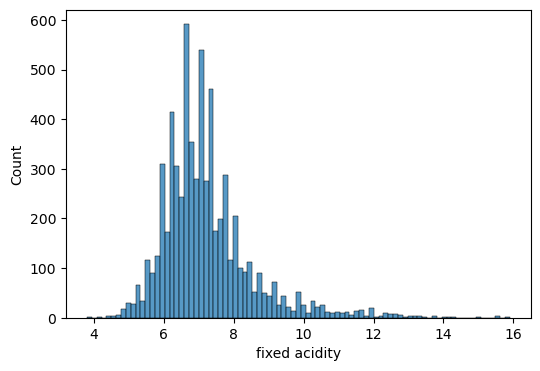

In [17]:
plt.figure(figsize= (6,4))
sns.histplot(data= df, x= 'fixed acidity')
plt.show()

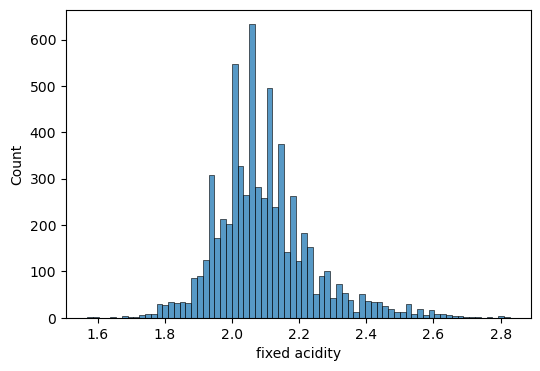

In [18]:
plt.figure(figsize= (6,4))
sns.histplot(data= df['fixed acidity'].apply(np.log1p))
plt.show()

In [23]:
# Preprocessing:

fixed_acidity_pipe = ImbPipeline([
    ('transformation', FunctionTransformer(np.log1p)),
    ('scaler', StandardScaler())
])

##### 2) volatile acidity:

In [28]:
df['volatile acidity']

0       0.70
1       0.88
2       0.76
3       0.28
4       0.70
        ... 
6492    0.21
6493    0.32
6494    0.24
6495    0.29
6496    0.21
Name: volatile acidity, Length: 6497, dtype: float64

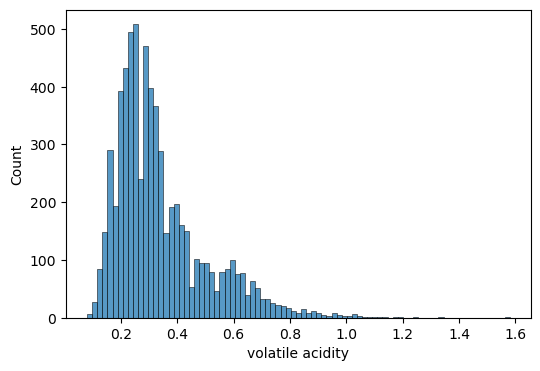

In [29]:
plt.figure(figsize= (6,4))
sns.histplot(data= df, x= 'volatile acidity')
plt.show()

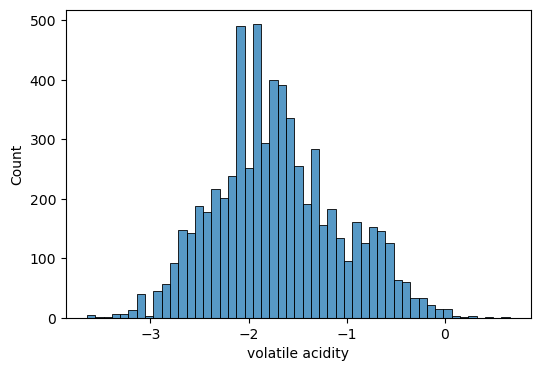

In [33]:
plt.figure(figsize= (6,4))
sns.histplot(data= df['volatile acidity'].apply(np.log2))
plt.show()

In [34]:
volatile_acidity_pipe = ImbPipeline([
    ('transformation', FunctionTransformer(np.log2)),
    ('scaler', StandardScaler())
])

##### 3) citric acid:

In [36]:
df['citric acid']

0       0.00
1       0.00
2       0.04
3       0.56
4       0.00
        ... 
6492    0.29
6493    0.36
6494    0.19
6495    0.30
6496    0.38
Name: citric acid, Length: 6497, dtype: float64

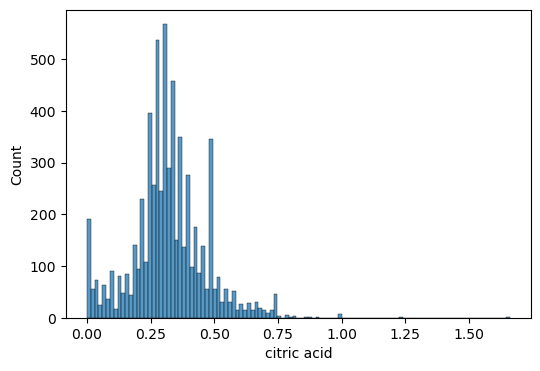

In [38]:
plt.figure(figsize= (6,4))
sns.histplot(data= df, x= 'citric acid')
plt.show()

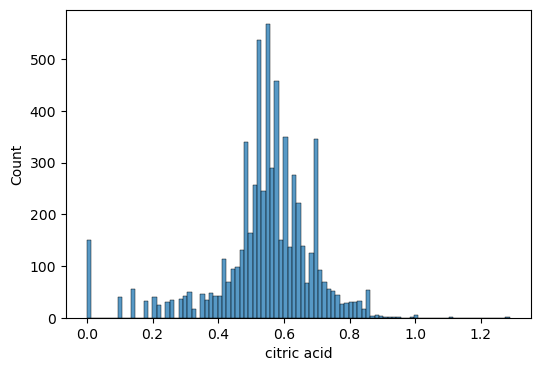

In [45]:
plt.figure(figsize= (6,4))
sns.histplot(data= df['citric acid'].apply(np.sqrt))
plt.show()

In [46]:
citric_acid_pipe = ImbPipeline([
    ('transformation', FunctionTransformer(np.sqrt)),
    ('scale', StandardScaler())
])

##### 4) residual sugar:

In [48]:
df['residual sugar']

0       1.9
1       2.6
2       2.3
3       1.9
4       1.9
       ... 
6492    1.6
6493    8.0
6494    1.2
6495    1.1
6496    0.8
Name: residual sugar, Length: 6497, dtype: float64

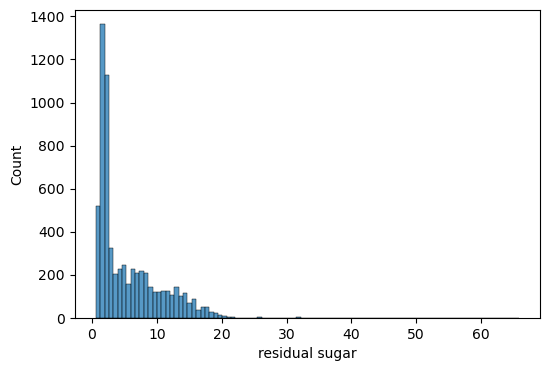

In [49]:
plt.figure(figsize= (6,4))
sns.histplot(data= df, x= 'residual sugar')
plt.show()

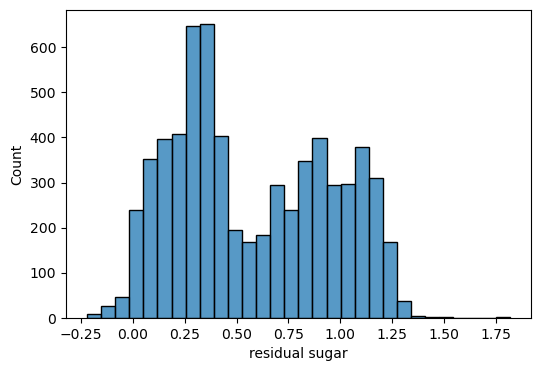

In [62]:
plt.figure(figsize= (6,4))
sns.histplot(data= df['residual sugar'].apply(np.log10))
plt.show()

In [63]:
residual_sugar_pipe = ImbPipeline([
    ('transformation', FunctionTransformer(np.log10)),
    ('scaler', StandardScaler())
])

##### 5) chlorides:

In [65]:
df['chlorides']

0       0.076
1       0.098
2       0.092
3       0.075
4       0.076
        ...  
6492    0.039
6493    0.047
6494    0.041
6495    0.022
6496    0.020
Name: chlorides, Length: 6497, dtype: float64

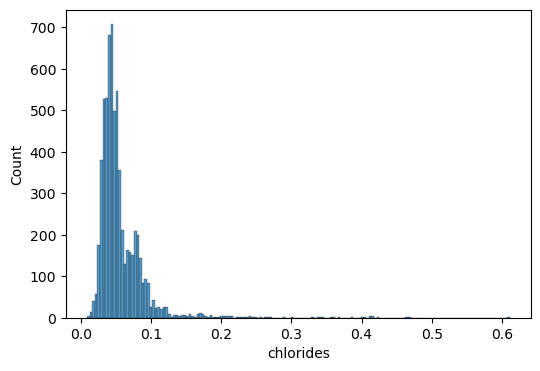

In [67]:
plt.figure(figsize= (6,4))
sns.histplot(data= df, x= 'chlorides')
plt.show()

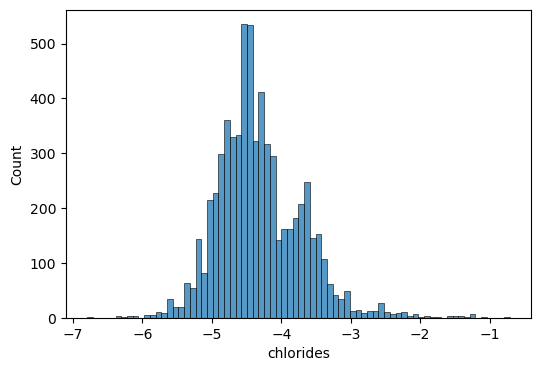

In [74]:
plt.figure(figsize= (6,4))
sns.histplot(data= df['chlorides'].apply(np.log2))
plt.show()

In [75]:
chlorides_piep = ImbPipeline([
    ('transformation', FunctionTransformer(np.log2)),
    ('scaler', StandardScaler())
])

##### 6) free sulfur dioxide:

In [77]:
df['free sulfur dioxide']

0       11.0
1       25.0
2       15.0
3       17.0
4       11.0
        ... 
6492    24.0
6493    57.0
6494    30.0
6495    20.0
6496    22.0
Name: free sulfur dioxide, Length: 6497, dtype: float64

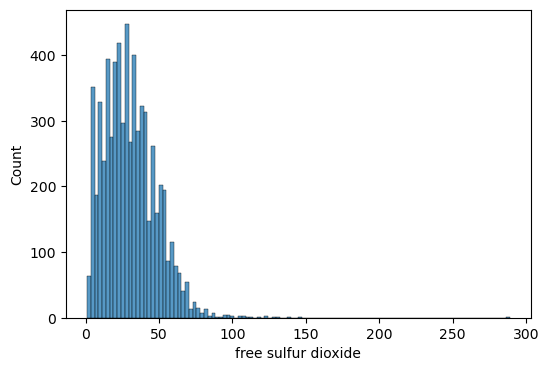

In [78]:
plt.figure(figsize= (6,4))
sns.histplot(data= df, x= 'free sulfur dioxide')
plt.show()

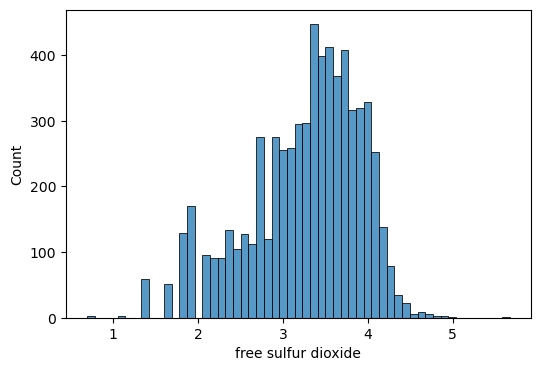

In [85]:
plt.figure(figsize= (6,4))
sns.histplot(data= df['free sulfur dioxide'].apply(np.log1p))
plt.show()

In [86]:
free_sulfur_pipe = ImbPipeline([
    ('transformation', FunctionTransformer(np.log1p)),
    ('scaler', StandardScaler())
])

##### 7) total sulfur dioxide:

In [88]:
df['total sulfur dioxide']

0        34.0
1        67.0
2        54.0
3        60.0
4        34.0
        ...  
6492     92.0
6493    168.0
6494    111.0
6495    110.0
6496     98.0
Name: total sulfur dioxide, Length: 6497, dtype: float64

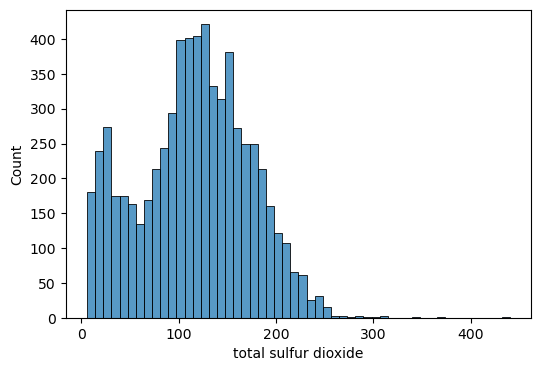

In [90]:
plt.figure(figsize= (6,4))
sns.histplot(data= df, x= 'total sulfur dioxide')
plt.show()

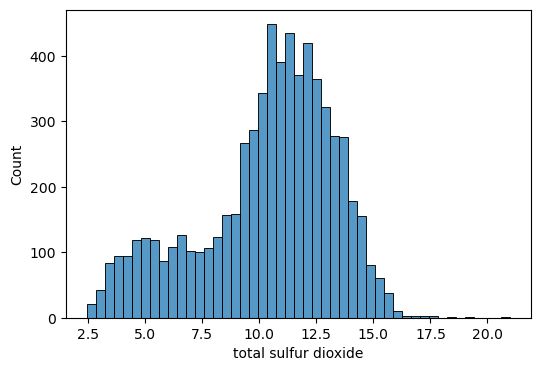

In [99]:
plt.figure(figsize= (6,4))
sns.histplot(data= df['total sulfur dioxide'].apply(np.sqrt))
plt.show()

In [100]:
total_sulfur_pipe = ImbPipeline([
    ('transformation', FunctionTransformer(np.sqrt)),
    ('scaler', StandardScaler())
])

##### 8) density:

In [102]:
df['density']

0       0.99780
1       0.99680
2       0.99700
3       0.99800
4       0.99780
         ...   
6492    0.99114
6493    0.99490
6494    0.99254
6495    0.98869
6496    0.98941
Name: density, Length: 6497, dtype: float64

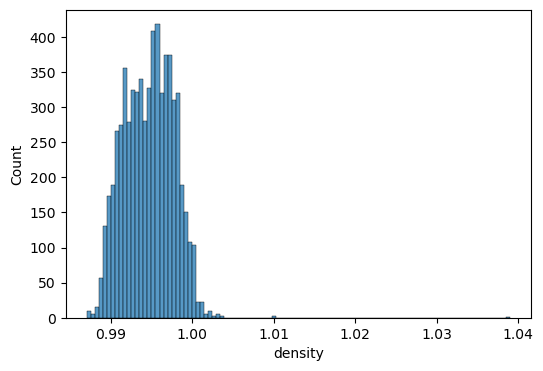

In [104]:
plt.figure(figsize= (6,4))
sns.histplot(data= df, x= 'density')
plt.show()

In [113]:
density_pipe = ImbPipeline([
    ('scaler', StandardScaler()) #None of the transformations work here.
])

##### 9) pH:

In [115]:
df['pH']

0       3.51
1       3.20
2       3.26
3       3.16
4       3.51
        ... 
6492    3.27
6493    3.15
6494    2.99
6495    3.34
6496    3.26
Name: pH, Length: 6497, dtype: float64

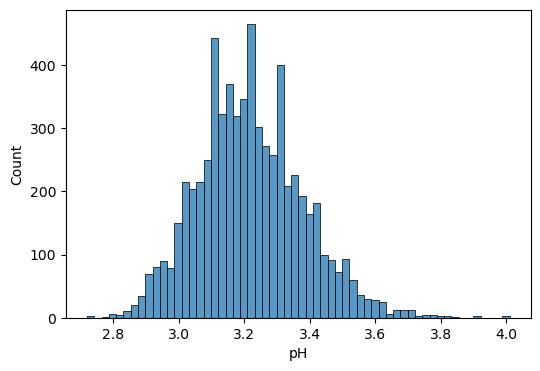

In [116]:
plt.figure(figsize= (6,4))
sns.histplot(data= df, x= 'pH')
plt.show()

In [117]:
ph_pipe = ImbPipeline([
    ('scaler', StandardScaler())
])

##### 10) sulphates:

In [119]:
df['sulphates']

0       0.56
1       0.68
2       0.65
3       0.58
4       0.56
        ... 
6492    0.50
6493    0.46
6494    0.46
6495    0.38
6496    0.32
Name: sulphates, Length: 6497, dtype: float64

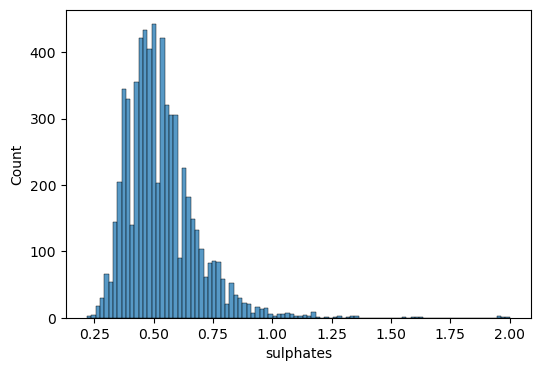

In [120]:
plt.figure(figsize= (6,4))
sns.histplot(data= df, x= 'sulphates')
plt.show()

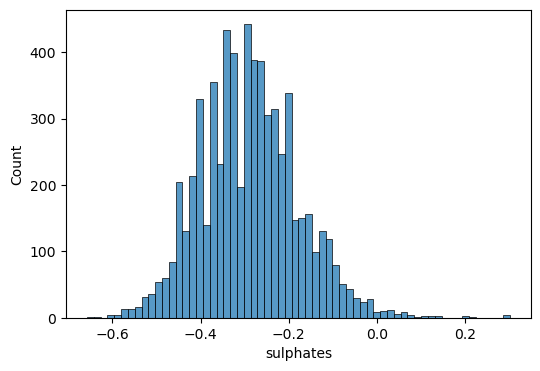

In [130]:
plt.figure(figsize= (6,4))
sns.histplot(data= df['sulphates'].apply(np.log10))
plt.show()

In [131]:
sulphates_pipe = ImbPipeline([
    ('transformation', FunctionTransformer(np.log10)),
    ('scaler', StandardScaler())
])

##### 11) alcohol:

In [133]:
df['alcohol']

0        9.4
1        9.8
2        9.8
3        9.8
4        9.4
        ... 
6492    11.2
6493     9.6
6494     9.4
6495    12.8
6496    11.8
Name: alcohol, Length: 6497, dtype: float64

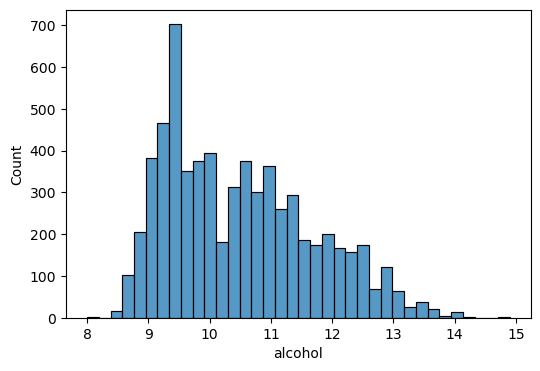

In [134]:
plt.figure(figsize= (6,4))
sns.histplot(data= df, x= 'alcohol')
plt.show()

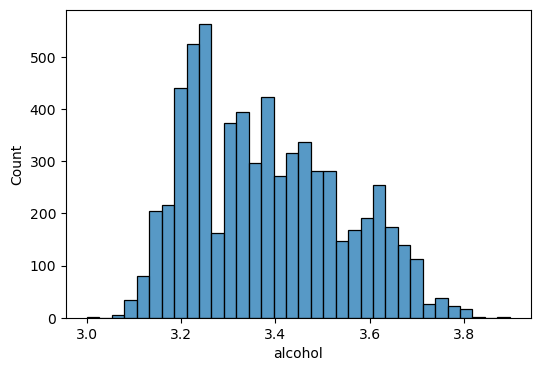

In [139]:
plt.figure(figsize= (6,4))
sns.histplot(data= df['alcohol'].apply(np.log2))
plt.show()

In [140]:
alcohol_pipe = ImbPipeline([
    ('transformation', FunctionTransformer(np.log2)),
    ('scaler', StandardScaler())
])

##### 12) type:

In [142]:
df['type']

0         red
1         red
2         red
3         red
4         red
        ...  
6492    white
6493    white
6494    white
6495    white
6496    white
Name: type, Length: 6497, dtype: object

In [143]:
df['type'].value_counts()

type
white    4898
red      1599
Name: count, dtype: int64

In [144]:
type_pipe = ImbPipeline([
    ('encoder', OneHotEncoder(handle_unknown= 'ignore'))
])

#### 4) Final Preprocessor:

In [146]:
preprocessor = ColumnTransformer([
    ('fixed acidity', fixed_acidity_pipe, ['fixed acidity']),
    ('volatile acidity', volatile_acidity_pipe, ['volatile acidity']),
    ('citric acid', citric_acid_pipe, ['citric acid']),
    ('residual sugar', residual_sugar_pipe, ['residual sugar']),
    ('chlorides', chlorides_piep, ['chlorides']),
    ('free sulfur dioxide', free_sulfur_pipe, ['free sulfur dioxide']),
    ('total sulfur dioxide', total_sulfur_pipe, ['total sulfur dioxide']),
    ('density', density_pipe, ['density']),
    ('pH', ph_pipe, ['pH']),
    ('sulphates', sulphates_pipe, ['sulphates']),
    ('alcohol', alcohol_pipe, ['alcohol']),
    ('type', type_pipe, ['type'])
], remainder= 'passthrough')

#### 5) Train Test Split:

In [147]:
X = df.drop('quality', axis= 1) #Features
y = df['quality'] #Target

In [148]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state= 42)

In [149]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(5197, 12)
(1300, 12)
(5197,)
(1300,)


#### 6) Model Building and Evaluation:
- We will try Support Vector Classifier without Over Sampling first.

##### 1) Support Vector Classifier (Without Over Sampling):

In [150]:
model_pipeline = ImbPipeline([
    ('Preprocessing', preprocessor),
    ('Model', SVC())
])

param_dict = {'Model__kernel': ['poly', 'linear', 'rbf', 'sigmoid'],
             'Model__C': [0.01, 0.1, 1, 10, 100],
             'Model__degree': [1,2,3],
             'Model__gamma': ['scale', 'auto'],
             }

grid_model = GridSearchCV(estimator= model_pipeline,
                         param_grid= param_dict,
                         scoring= 'roc_auc',
                         cv= 5,
                         n_jobs= -1)

In [151]:
# Fitting The Grid Model:

grid_model.fit(X_train, y_train)

,estimator,"Pipeline(step...del', SVC())])"
,param_grid,"{'Model__C': [0.01, 0.1, ...], 'Model__degree': [1, 2, ...], 'Model__gamma': ['scale', 'auto'], 'Model__kernel': ['poly', 'linear', ...]}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('fixed acidity', ...), ('volatile acidity', ...), ...]"


In [152]:
# Best Estimator according to Grid Search:

print(grid_model.best_score_)
print(grid_model.best_params_)

0.7372555128205128
{'Model__C': 100, 'Model__degree': 2, 'Model__gamma': 'scale', 'Model__kernel': 'poly'}


In [153]:
# Predictions Using Best Estimator from Grid:

y_pred = grid_model.predict(X_test)

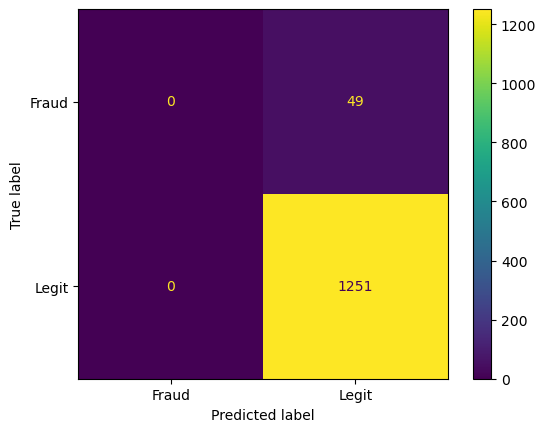

In [156]:
# Confusion Matrix:

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels= grid_model.classes_)
disp.plot()
plt.show()

In [157]:
# Classification Report:

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       Fraud       0.00      0.00      0.00        49
       Legit       0.96      1.00      0.98      1251

    accuracy                           0.96      1300
   macro avg       0.48      0.50      0.49      1300
weighted avg       0.93      0.96      0.94      1300



##### 2) Support Vector Classifier (WithOver Sampling):

In [160]:
model_pipeline = ImbPipeline([
    ('Preprocessing', preprocessor),
    ('Over_Sampling', SMOTE()),
    ('Model', SVC())
])

param_dict = {'Over_Sampling__sampling_strategy': [0.5, 0.75, 'minority'],
            'Model__kernel': ['poly', 'linear', 'rbf', 'sigmoid'],
             'Model__C': [0.01, 0.1, 1, 10, 100],
             'Model__degree': [1,2,3],
             'Model__gamma': ['scale', 'auto'],
             }

grid_model = GridSearchCV(estimator= model_pipeline,
                         param_grid= param_dict,
                         scoring= 'roc_auc',
                         cv= 5,
                         n_jobs= -1)

In [161]:
# Fitting The Grid Model:

grid_model.fit(X_train, y_train)

,estimator,"Pipeline(step...del', SVC())])"
,param_grid,"{'Model__C': [0.01, 0.1, ...], 'Model__degree': [1, 2, ...], 'Model__gamma': ['scale', 'auto'], 'Model__kernel': ['poly', 'linear', ...], ...}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('fixed acidity', ...), ('volatile acidity', ...), ...]"


In [162]:
# Best Estimator according to Grid Search:

print(grid_model.best_score_)
print(grid_model.best_params_)

0.8171278205128205
{'Model__C': 0.1, 'Model__degree': 2, 'Model__gamma': 'scale', 'Model__kernel': 'rbf', 'Over_Sampling__sampling_strategy': 0.5}


In [163]:
# Predictions Using Best Estimator from Grid:

y_pred = grid_model.predict(X_test)

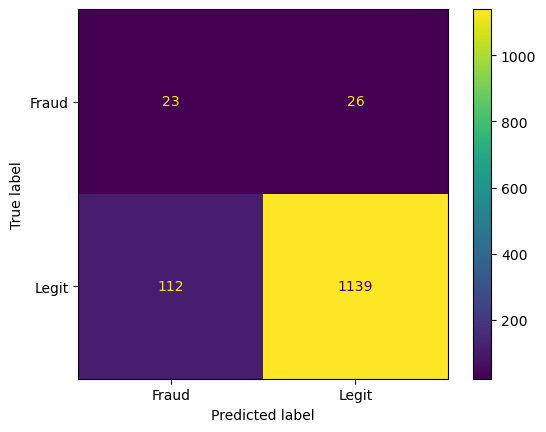

In [164]:
# Confusion Matrix:

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels= grid_model.classes_)
disp.plot()
plt.show()

In [165]:
# Classification Report:

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       Fraud       0.17      0.47      0.25        49
       Legit       0.98      0.91      0.94      1251

    accuracy                           0.89      1300
   macro avg       0.57      0.69      0.60      1300
weighted avg       0.95      0.89      0.92      1300



- There's a slight improvement in all of Precision, Recall and F1-Score for Fraud Detection after Over Sampling.